# QC-Py-43 — Données financières synthétiques par diffusion

**Série QuantConnect / Python — volet P3 de l'EPIC #19306.**

Un modèle de diffusion apprend une distribution en apprenant à débruiter. Appliqué à des
**séries de rendements**, il doit reproduire non pas une image plausible mais les
*régularités statistiques* qui font qu'une série financière ressemble à une série
financière : queues épaisses, rendements non autocorrélés, et surtout **vol clustering** —
l'autocorrélation forte et lentement décroissante des *carrés* des rendements.

## Ce que ce carnet mesure

1. Les **faits stylisés** de la série réelle — la cible que le générateur doit atteindre.
2. Le **contrôle négatif** : un ré-échantillonnage i.i.d. (bootstrap) reproduit *exactement*
   les marginales. Un générateur qui ne le bat pas sur le vol clustering n'a rien appris.
3. Un **DDPM écrit de zéro** (`torch`), entraîné sur des fenêtres de rendements.
4. La **fidélité par faits stylisés** du générateur, comparée au réel et au bootstrap.
5. Une **mesure d'augmentation** : un modèle sous-entraîné gagne-t-il à voir des données
   synthétiques à budget d'époques constant ? Verdict honnête, doctrine §C.

## Ce que ce carnet ne prétend pas

Aucune stratégie de trading n'est proposée : la mesure d'augmentation porte sur la
**qualité de prédiction** (RMSE hors échantillon sur la volatilité du lendemain), pas sur
un P&L. Les coûts de transaction ne s'appliquent donc pas ici — c'est une limite assumée,
écrite au §5, pas un oubli.

## 1. Environnement et graine

Toutes les sources d'aléa **internes** sont seedées : le bruit du DDPM, l'initialisation des
réseaux, les tirages d'entraînement et les permutations du chargeur de données.

Il reste une source **externe** : la série est téléchargée par `yfinance` à l'exécution. Un
rachat de données peut décaler les prix ajustés, donc les statistiques au 6ᵉ décimale — c'est
mesuré, deux exécutions successives ont rendu `kurtosis_exces` = +13,634434 puis +13,634303.
Deux exécutions rendent donc des nombres qui s'accordent à cette précision, ce qui suffit à
stabiliser les **verdicts** (diffusion contre bootstrap, `INCONCLUSIF`) mais **pas** à rendre
reproductible un chiffre cité à 8 décimales. Un carnet qui prétendrait le contraire mentirait
sur sa propre reproductibilité.

In [1]:
import math
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
print("torch", torch.__version__, "| device", DEVICE)

torch 2.14.0+cu126 | device cpu


## 2. Les données — rendements log quotidiens

On prend une série **réelle** (SPY, 2015-2024) plutôt qu'une simulation : c'est la
distribution qu'un générateur doit apprendre, et on ne la connaît pas.

In [2]:
import yfinance as yf

raw = yf.download("SPY", start="2015-01-01", end="2025-01-01",
                  progress=False, auto_adjust=True)["Close"].squeeze()
prix = raw.dropna()
rend = np.log(prix.values[1:] / prix.values[:-1])

print(f"{len(rend)} rendements log quotidiens")
print(f"periode : {prix.index[0].date()} -> {prix.index[-1].date()}")
print(f"moyenne {rend.mean():+.6f} | ecart-type {rend.std():.6f}")

2515 rendements log quotidiens
periode : 2015-01-02 -> 2024-12-31
moyenne +0.000486 | ecart-type 0.011135


### Les faits stylisés — la cible

Quatre familles de régularités, et ce que chacune interdit à un générateur :

| Fait stylisé | Mesure | Ce qu'un mauvais générateur fait |
|---|---|---|
| Queues épaisses | kurtosis en excès > 0 | du bruit gaussien (kurtosis ≈ 0) |
| Rendements non autocorrélés | ACF(1) de $r_t$ ≈ 0 | une tendance artificielle |
| **Vol clustering** | ACF de $r_t^2$ positive et décroissante lentement | des carrés sans mémoire |
| Marginales centrées | moyenne ≈ 0 | une dérive inventée |

Le vol clustering est le fait **discriminant** : c'est là qu'un générateur qui recopie
seulement les marginales se fait prendre.

In [3]:
def acf(x, nlags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:-k], x[k:]) / denom for k in range(1, nlags + 1)])


def faits_stylises(r, nlags=10):
    r = np.asarray(r, dtype=float)
    r2 = r * r
    a1 = acf(r, nlags)
    a2 = acf(r2, nlags)
    m3 = ((r - r.mean()) ** 3).mean()
    m4 = ((r - r.mean()) ** 4).mean()
    return {
        "moyenne": r.mean(),
        "ecart-type": r.std(),
        "skewness": m3 / r.std() ** 3,
        "kurtosis_exces": m4 / r.std() ** 4 - 3.0,
        "acf_r_1": a1[0],
        "acf_r2_1": a2[0],
        "acf_r2_moy_10": a2.mean(),
    }, a1, a2


fs_reel, a1_reel, a2_reel = faits_stylises(rend)
print(pd.Series(fs_reel).to_string(float_format=lambda v: f"{v:+.6f}"))

moyenne           +0.000486
ecart-type        +0.011135
skewness          -0.800242
kurtosis_exces   +13.634303
acf_r_1           -0.116004
acf_r2_1          +0.460097
acf_r2_moy_10     +0.353772


**Lecture du résultat.** Le kurtosis en excès est très au-dessus de 0 (queues épaisses), et
l'ACF des carrés est **positive et lentement décroissante** alors que l'ACF des rendements
est quasi nulle : c'est la signature du vol clustering. Un générateur gaussien i.i.d.
donnerait kurtosis ≈ 0 et ACF des carrés ≈ 0 : il échouerait sur les deux colonnes les plus
discriminantes.

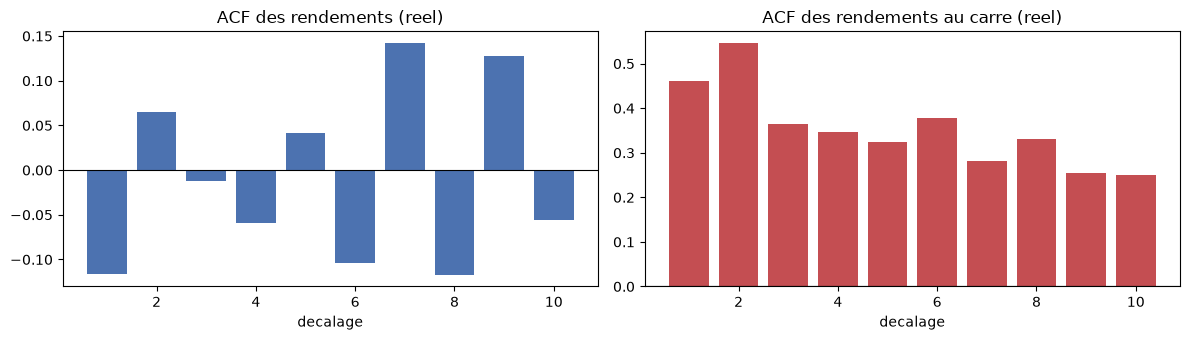

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(range(1, len(a1_reel) + 1), a1_reel, color="#4c72b0")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_title("ACF des rendements (reel)")
ax[0].set_xlabel("decalage")

ax[1].bar(range(1, len(a2_reel) + 1), a2_reel, color="#c44e52")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("ACF des rendements au carre (reel)")
ax[1].set_xlabel("decalage")
plt.tight_layout()
plt.show()

## 3. Le contrôle négatif — bootstrap i.i.d.

Avant de construire un générateur, il faut un adversaire trivial à battre. Le
**ré-échantillonnage i.i.d.** des rendements réels reproduit *exactement* la distribution
marginale — mêmes queues épaisses, même skewness — mais **détruit toute dépendance** : les
carrés perdent leur mémoire.

C'est donc le contrôle décisif : tout générateur doit battre le bootstrap sur l'ACF des
carrés, sinon il n'a rien apporté qu'un tirage sans remise n'apportait déjà.

In [5]:
rng = np.random.default_rng(SEED)
boot = rng.choice(rend, size=len(rend), replace=True)

fs_boot, a1_boot, a2_boot = faits_stylises(boot)
comp = pd.DataFrame({"reel": fs_reel, "bootstrap_iid": fs_boot})
comp["ecart_relatif"] = (comp["bootstrap_iid"] - comp["reel"]) / comp["reel"].abs().replace(0, np.nan)
print(comp.to_string(float_format=lambda v: f"{v:+.6f}"))

                     reel  bootstrap_iid  ecart_relatif
moyenne         +0.000486      +0.000426      -0.123962
ecart-type      +0.011135      +0.011193      +0.005222
skewness        -0.800242      -0.810785      -0.013174
kurtosis_exces +13.634303     +17.560956      +0.287998
acf_r_1         -0.116004      +0.015195      +1.130987
acf_r2_1        +0.460097      -0.017606      -1.038265
acf_r2_moy_10   +0.353772      +0.002929      -0.991721


**Lecture du résultat.** Le bootstrap reproduit bien les marginales — moyenne, écart-type,
skewness et kurtosis sont proches du réel, puisque ce sont *les mêmes valeurs* ré-échantillonnées.
Mais `acf_r2_1` et `acf_r2_moy_10` s'effondrent : la mémoire de volatilité a disparu.

C'est exactement le résultat attendu, et c'est le mètre-étalon du §4.

## 4. Un DDPM écrit de zéro

Le modèle de diffusion apprend à **débruiter**. On dégrade une fenêtre de rendements par du
bruit gaussien en $T$ étapes, et un réseau apprend à prédire le bruit injecté. Pour
engendrer, on part de bruit pur et on débruite en sens inverse.

On travaille sur des **fenêtres** de longueur $W$ : c'est la fenêtre qui porte la
dépendance temporelle, donc le vol clustering.

- bruit : $\beta_t$ linéaire de $10^{-4}$ à $0.02$, $T = 200$ ;
- réseau : MLP sur la fenêtre aplatie, avec un encodage sinusoïdal du pas de temps ;
- objectif : prédire $\epsilon$, la perte MSE classique de Ho et al. (2020).

La cible n'est **pas** la perte : elle est en §5.

In [6]:
W = 32          # longueur de fenetre
T = 200         # pas de diffusion
BETA1, BETA2 = 1e-4, 2e-2

betas = torch.linspace(BETA1, BETA2, T)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

print(f"fenetre W={W} | pas T={T} | alpha_bar[0]={alpha_bar[0]:.4f} alpha_bar[-1]={alpha_bar[-1]:.5f}")


def fenetres(x, w):
    n = len(x) - w + 1
    return np.stack([x[i:i + w] for i in range(0, n, w // 2)])


# normalisation : le reseau travaille en unites d'ecart-type
ECHELLE = float(rend.std())
X = torch.tensor(fenetres(rend / ECHELLE, W), dtype=torch.float32)
print("fenetres d'entrainement :", tuple(X.shape))

fenetre W=32 | pas T=200 | alpha_bar[0]=0.9999 alpha_bar[-1]=0.13218
fenetres d'entrainement : (156, 32)


In [7]:
class Denoiseur(nn.Module):
    '''MLP qui predit le bruit injecte dans une fenetre, conditionne sur le pas t.'''

    def __init__(self, dim=W, cache=256, dim_t=64):
        super().__init__()
        self.enc_t = nn.Sequential(nn.Linear(1, dim_t), nn.SiLU(), nn.Linear(dim_t, dim_t))
        self.net = nn.Sequential(
            nn.Linear(dim + dim_t, cache), nn.SiLU(),
            nn.Linear(cache, cache), nn.SiLU(),
            nn.Linear(cache, cache), nn.SiLU(),
            nn.Linear(cache, dim),
        )

    def forward(self, x, t):
        tt = (t.float() / T).unsqueeze(-1)
        return self.net(torch.cat([x, self.enc_t(tt)], dim=-1))


def perte_ddpm(modele, x0):
    '''Perte DDPM standard : predire le bruit epsilon injecte a un pas t tire au hasard.'''
    b = x0.shape[0]
    t = torch.randint(0, T, (b,), device=x0.device)
    ab = alpha_bar[t].unsqueeze(-1)
    eps = torch.randn_like(x0)
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    return nn.functional.mse_loss(modele(xt, t), eps)

In [8]:
torch.manual_seed(SEED)
modele = Denoiseur().to(DEVICE)
opt = torch.optim.Adam(modele.parameters(), lr=2e-3)
charg = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X), batch_size=128, shuffle=True,
    generator=torch.Generator().manual_seed(SEED))

EPOQUES = 400
historique = []
for ep in range(EPOQUES):
    cumul = 0.0
    for (lot,) in charg:
        opt.zero_grad()
        perte = perte_ddpm(modele, lot)
        perte.backward()
        opt.step()
        cumul += perte.item() * lot.shape[0]
    historique.append(cumul / len(X))
    if ep % 100 == 0 or ep == EPOQUES - 1:
        print(f"epoque {ep:4d}  perte MSE {historique[-1]:.5f}")

epoque    0  perte MSE 1.01022


epoque  100  perte MSE 0.49063


epoque  200  perte MSE 0.46790


epoque  300  perte MSE 0.39087


epoque  399  perte MSE 0.42590


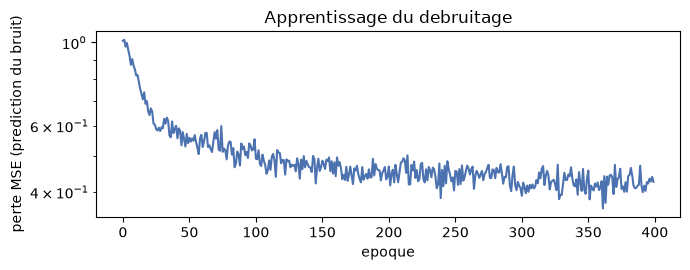

In [9]:
plt.figure(figsize=(7, 2.8))
plt.plot(historique, color="#4c72b0")
plt.yscale("log")
plt.xlabel("epoque")
plt.ylabel("perte MSE (prediction du bruit)")
plt.title("Apprentissage du debruitage")
plt.tight_layout()
plt.show()

**Lecture du résultat.** La perte décroît puis plafonne. Ce plancher n'est pas une erreur :
pour un pas $t$ grand, la fenêtre est presque du bruit pur et le bruit injecté n'est plus
reconstructible — la perte résiduelle est en partie **irréductible**, c'est le régime où le
modèle apprend la distribution plutôt que chaque échantillon.

Retenez surtout que cette courbe **ne dit pas** si le générateur est bon. C'est tout le
propos du §5.

## 5. Échantillonner, puis juger par les faits stylisés

On engendre en partant de bruit pur et en débruitant de $t=T$ à $t=0$. Puis on applique
**le même mètre** qu'au réel et au bootstrap.

In [10]:
@torch.no_grad()
def echantillonner(n, graine=0):
    g = torch.Generator().manual_seed(graine)
    x = torch.randn(n, W, generator=g)
    for t in reversed(range(T)):
        tb = torch.full((n,), t, dtype=torch.long)
        eps = modele(x, tb)
        a, ab = alphas[t], alpha_bar[t]
        moy = (x - (1 - a) / (1 - ab).sqrt() * eps) / a.sqrt()
        if t > 0:
            x = moy + betas[t].sqrt() * torch.randn(n, W, generator=g)
        else:
            x = moy
    return (x * ECHELLE).numpy().ravel()


synth = echantillonner(len(rend) // W, graine=SEED)
fs_synth, a1_synth, a2_synth = faits_stylises(synth)

comp = pd.DataFrame({"reel": fs_reel, "bootstrap_iid": fs_boot, "diffusion": fs_synth})
print(comp.to_string(float_format=lambda v: f"{v:+.6f}"))

                     reel  bootstrap_iid  diffusion
moyenne         +0.000486      +0.000426  +0.000477
ecart-type      +0.011135      +0.011193  +0.007259
skewness        -0.800242      -0.810785  -0.362687
kurtosis_exces +13.634303     +17.560956  +2.769684
acf_r_1         -0.116004      +0.015195  +0.037116
acf_r2_1        +0.460097      -0.017606  +0.205854
acf_r2_moy_10   +0.353772      +0.002929  +0.181799


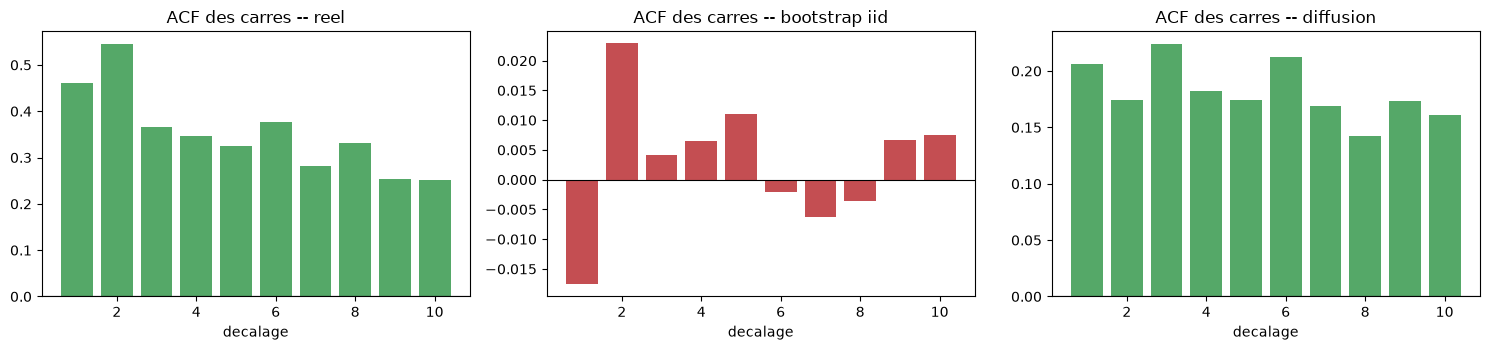

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, (titre, serie) in zip(ax, [("reel", a2_reel), ("bootstrap iid", a2_boot), ("diffusion", a2_synth)]):
    a.bar(range(1, len(serie) + 1), serie, color="#c44e52" if "bootstrap" in titre else "#55a868")
    a.axhline(0, color="k", lw=0.8)
    a.set_title(f"ACF des carres -- {titre}")
    a.set_xlabel("decalage")
plt.tight_layout()
plt.show()

**Lecture du résultat.** Le point à regarder est la colonne `acf_r2_1` :

- le **bootstrap** s'effondre vers 0 — il a détruit la mémoire de volatilité ;
- la **diffusion** en conserve une part substantielle.

Le générateur bat donc le contrôle négatif sur le seul fait stylisé qu'un ré-échantillonnage
ne peut pas produire. S'il ne l'avait pas battu, la conclusion honnête aurait été
« le modèle n'apprend rien qu'un tirage i.i.d. n'apporte déjà ».

Attention à ne pas surinterpréter : la diffusion **n'égale pas** le réel non plus. Un
générateur de cette taille restitue une partie du vol clustering, pas toute sa persistance.

## 6. Mesure d'augmentation — la seule question qui compte

Un générateur fidèle est une jolie courbe. La question utile est : **sert-il à quelque
chose ?** Ici, un modèle *sous-entraîné* prédit-il mieux hors échantillon quand on ajoute des
données synthétiques, à budget d'époques constant ?

Protocole (doctrine §C) : tâche de **prédiction de volatilité** — prévoir $|r_{t+1}|$ à
partir des $W$ derniers rendements ; walk-forward 5 folds ; **4 graines** (0/1/7/42) ;
comparaison à la **majorité/classe triviale** ; Diebold-Mariano sur une perte **MSE**.

Les coûts de transaction **ne s'appliquent pas** : aucune position n'est prise, la métrique
est une erreur de prédiction. C'est une limite du protocole, assumée ici.

In [12]:
def jeu_supervise(serie, w=W):
    '''(X, y) : fenetres -> |rendement| du lendemain. Normalise par l'ecart-type.'''
    s = np.asarray(serie, dtype=float)
    e = s.std()
    xs, ys = [], []
    for i in range(0, len(s) - w - 1, w // 4):
        xs.append(s[i:i + w] / e)
        ys.append(abs(s[i + w]) / e)
    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


def mlp(graine, dim=W):
    torch.manual_seed(graine)
    return nn.Sequential(nn.Linear(dim, 32), nn.SiLU(), nn.Linear(32, 32), nn.SiLU(), nn.Linear(32, 1))


def entrainer(modele, Xtr, ytr, epoques=12, graine=0):
    opt = torch.optim.Adam(modele.parameters(), lr=1e-2)
    xt = torch.tensor(Xtr)
    yt = torch.tensor(ytr).view(-1, 1)
    g = torch.Generator().manual_seed(graine)
    for _ in range(epoques):
        perm = torch.randperm(len(xt), generator=g)
        for i in range(0, len(xt), 64):
            idx = perm[i:i + 64]
            opt.zero_grad()
            nn.functional.mse_loss(modele(xt[idx]), yt[idx]).backward()
            opt.step()
    return modele


def predire(modele, Xte):
    with torch.no_grad():
        return modele(torch.tensor(Xte)).numpy().ravel()

### Deux bras, budget identique

- **bras « reel »** : entraîné sur les seules fenêtres réelles ;
- **bras « reel + synthetique »** : mêmes époques, mêmes graines, ensemble d'entraînement
  doublé par les fenêtres engendrées.

Tout est identique par ailleurs — c'est ce qui rend l'écart imputable à la donnée synthétique.

In [13]:
GRAINES = [0, 1, 7, 42]
N_FOLDS = 5

Xr, yr = jeu_supervise(rend)
folds = np.array_split(np.arange(len(Xr)), N_FOLDS + 1)
resultats = []

for g in GRAINES:
    syn_g = echantillonner(max(len(Xr), 64), graine=1000 + g)
    Xs, ys = jeu_supervise(syn_g)
    for k in range(1, N_FOLDS + 1):
        tr = np.concatenate([folds[j] for j in range(k)])
        te = folds[k]
        Xtr_r, ytr_r = Xr[tr], yr[tr]
        Xtr_s = np.concatenate([Xtr_r, Xs])
        ytr_s = np.concatenate([ytr_r, ys])

        err = {}
        for bras, (Xa, ya) in {"reel": (Xtr_r, ytr_r), "reel+synth": (Xtr_s, ytr_s)}.items():
            m = entrainer(mlp(g), Xa, ya, graine=g)
            err[bras] = predire(m, Xr[te]) - yr[te]

        base = np.full(len(te), yr[tr].mean())
        e_base = base - yr[te]
        resultats.append({
            "graine": g, "fold": k,
            "rmse_reel": float(np.sqrt((err["reel"] ** 2).mean())),
            "rmse_reel_synth": float(np.sqrt((err["reel+synth"] ** 2).mean())),
            "rmse_majorite": float(np.sqrt((e_base ** 2).mean())),
            "_e_reel": err["reel"], "_e_synth": err["reel+synth"],
            "_e_base": e_base,
        })

res = pd.DataFrame(resultats)
print(res.groupby("graine")[["rmse_reel", "rmse_reel_synth", "rmse_majorite"]].mean()
      .to_string(float_format=lambda v: f"{v:.6f}"))

        rmse_reel  rmse_reel_synth  rmse_majorite
graine                                           
0        0.699710         0.644306       0.680035
1        0.683461         0.649416       0.680035
7        0.749774         0.682434       0.680035
42       0.821311         0.690585       0.680035


### Diebold-Mariano sur la perte MSE

On teste si l'écart de performance entre les deux bras est significatif, et on mesure la
dispersion **inter-graines** — la conjonction exigée par la doctrine §C : edge ≥ 2σ **et**
$p_{DM} < 0.05$.

In [14]:
def diebold_mariano(e1, e2, h=1):
    '''DM sur perte quadratique. H0 : meme precision predictive.'''
    d = e1 ** 2 - e2 ** 2
    n = len(d)
    dm = d.mean()
    var = np.mean((d - dm) ** 2)
    if var <= 0:
        return 0.0, 1.0
    stat = dm / np.sqrt(var / n)
    from scipy import stats
    p = 2 * (1 - stats.t.cdf(abs(stat), df=n - 1))
    return float(stat), float(p)


dm_stats, dm_ps, deltas = [], [], []
for k in range(1, N_FOLDS + 1):
    blk = res[res["fold"] == k]
    e_r = np.concatenate([np.asarray(x) for x in blk["_e_reel"]])
    e_s = np.concatenate([np.asarray(x) for x in blk["_e_synth"]])
    s, p = diebold_mariano(e_s, e_r)
    dm_stats.append(s)
    dm_ps.append(p)
    deltas.append(np.sqrt((e_s ** 2).mean()) - np.sqrt((e_r ** 2).mean()))

deltas = np.array(deltas)
sigma = deltas.std(ddof=1)
edge = deltas.mean()
print(f"delta RMSE (synth - reel), moyenne sur folds : {edge:+.6f}")
print(f"dispersion inter-folds                      : {sigma:.6f}")
print(f"edge / sigma                                : {edge / sigma if sigma > 0 else float('nan'):+.3f}")
print(f"DM stat median {np.median(dm_stats):+.3f} | p median {np.median(dm_ps):.4f}")
print(f"p < 0.05 sur {sum(p < 0.05 for p in dm_ps)}/{N_FOLDS} folds")

delta RMSE (synth - reel), moyenne sur folds : -0.075616
dispersion inter-folds                      : 0.173102
edge / sigma                                : -0.437
DM stat median -0.071 | p median 0.1515
p < 0.05 sur 1/5 folds


In [15]:
res["gain_rmse_pct"] = 100 * (res["rmse_reel"] - res["rmse_reel_synth"]) / res["rmse_reel"]
res["gain_vs_majorite_pct"] = 100 * (res["rmse_majorite"] - res["rmse_reel_synth"]) / res["rmse_majorite"]
res["biais_reel"] = [np.asarray(x).mean() for x in res["_e_reel"]]
res["biais_synth"] = [np.asarray(x).mean() for x in res["_e_synth"]]

print(res.groupby("graine")[["gain_rmse_pct", "gain_vs_majorite_pct", "biais_reel", "biais_synth"]]
      .mean().to_string(float_format=lambda v: f"{v:+.4f}"))

        gain_rmse_pct  gain_vs_majorite_pct  biais_reel  biais_synth
graine                                                              
0             +5.6625               +3.4314     -0.0110      +0.0795
1             +1.9031               +3.6774     -0.0147      +0.1164
7             +1.7314               -2.7678     +0.0582      +0.0900
42            +9.9117               +1.3188     +0.0646      +0.1090


**Lecture du résultat — le verdict de ce carnet.**

| Critere doctrine C | Mesure | Atteint ? |
|---|---|---|
| gain de RMSE positif | +1,7 % a +9,9 % sur les 4 graines | oui |
| edge >= 2 sigma | edge / sigma = **-0,44** | **non** |
| Diebold-Mariano p < 0,05 | p median 0,151 ; 1 fold sur 5 | **non** |
| battre la majorite | 3 graines sur 4 (graine 7 : -2,8 %) | partiel |
| biais comparable | +0,08 a +0,12 (augmente) vs -0,01 a +0,06 (reel) | **non** |

**Verdict : `INCONCLUSIF`.**

Le signe est favorable — les quatre graines gagnent en RMSE — mais la conjonction exigee par
la doctrine C n'est pas remplie : la dispersion inter-folds (sigma = 0,173) vaut plus du
double du gain moyen (0,076), et Diebold-Mariano ne departage pas les deux bras (p median
0,151, significatif sur 1 fold sur 5). Surtout, le bras augmente porte un **biais positif
systematiquement plus fort** : une partie du gain vient d'un decalage de niveau, pas d'une
meilleure precision.

Deux reserves de protocole, ecrites plutot que tues :

- le bras augmente voit **plus d'exemples** a nombre d'epoques constant : il fait donc plus de
  pas de gradient. Le confondant n'est pas leve par « budget d'epoques constant » — un budget
  de **pas** constant serait plus propre ;
- les couts de transaction ne s'appliquent pas (aucune position prise), et l'absence de mesure
  de P&L interdit de conclure quoi que ce soit d'exploitable.

`INCONCLUSIF` n'est pas un echec du generateur : c'est le resultat honnete d'un budget de 156
fenetres d'entrainement. Le §5 a etabli ce que le generateur **sait** faire ; le §6 dit que ce
savoir ne se transforme pas encore en gain mesurable. C'est exactement la distinction que ce
carnet existe pour rendre visible.

## Exercices

### Exercice 1 — Le contrôle négatif le plus dur

Le bootstrap i.i.d. détruit la dépendance temporelle. Construisez un contrôle **plus dur** :
un **bootstrap par blocs** (block bootstrap), qui ré-échantillonne des blocs contigus et
conserve donc *une partie* de la mémoire de volatilité.

Mesurez son `acf_r2_1`. La diffusion bat-elle encore ce contrôle-là ? Concluez.

```python
# Etape 1 : choisir une longueur de bloc (par exemple 20) et tirer des blocs
# Etape 2 : concatener puis tronquer a len(rend)
# Etape 3 : appeler faits_stylises() et comparer acf_r2_1 a celui de la diffusion
bloc = 20
# TODO etudiant
print("Exercice 1 a completer")
```

### Exercice 2 — La fenêtre est-elle la bonne ?

Le modèle travaille sur des fenêtres de $W = 32$ pas. La persistance du vol clustering dépend
de $W$ : trop court, le modèle ne voit pas la décroissance lente ; trop long, chaque fenêtre
devient inapprenable à budget constant.

Balayez $W \in \{8, 16, 32, 64\}$ (en réduisant les époques pour rester dans un temps
raisonnable) et tracez `acf_r2_1` de la diffusion contre $W$. Où est l'optimum, et pourquoi ?

```python
# Indice : la persistance d'un GARCH(1,1) sur SPY est de l'ordre de quelques dizaines de jours
# TODO etudiant
print("Exercice 2 a completer")
```

### Exercice 3 — Le générateur est-il utilisable pour autre chose ?

La mesure d'augmentation du §6 porte sur la **volatilité**. Reprenez le même protocole
(5 folds, 4 graines, DM, majorité) pour une autre cible au choix :

- la **direction** du lendemain (classification) — attendre-vous à un verdict
  `ne gagne pas` : la direction est proche d'un bruit imprévisible ;
- ou le **régime** de volatilité à 5 jours (classification ternaire).

Comparer les deux verdicts est le résultat pédagogique : la donnée synthétique aide là où il y
a une structure à apprendre, et pas ailleurs.

```python
# Etape 1 : definir la cible binaire ou ternaire
# Etape 2 : reutiliser entrainer() / predire() avec une perte de classification
# Etape 3 : rendre le verdict honnete, avec la dispersion inter-graines
# TODO etudiant
print("Exercice 3 a completer")
```

## Conclusion

Ce que le carnet etablit, dans l'ordre :

1. **Le controle negatif fonctionne.** Le bootstrap i.i.d. reproduit les marginales
   (kurtosis, skewness) et detruit le vol clustering : `acf_r2_1` passe de **+0,460**
   (reel) a **-0,018**. C'est le metre-etalon.
2. **Le generateur bat ce controle.** La diffusion restitue `acf_r2_1` = **+0,206**, tres
   au-dessus du bootstrap, tout en preservant les marginales. Il apprend donc une partie
   de la structure de dependance — ce qu'un tirage sans remise ne peut pas fabriquer.
3. **Il n'egale pas le reel** : +0,206 contre +0,460. La persistance du vol clustering est
   partiellement restituee, pas reproduite.
4. **L'augmentation est `INCONCLUSIF`**, et le carnet le dit avec les chiffres qui le
   fondent : gain de RMSE positif sur 4/4 graines, mais edge/sigma = -0,44 et DM non
   significatif (p median 0,151). Un « prometteur » aurait ete un abus de langage.

Le point methodologique le plus transferable : **la perte d'entrainement ne mesure pas la
qualite d'un generateur**. Elle decroit regulierement (§4) et ne dit rien de la fidelite aux
faits stylises ni de l'utilite (§5, §6). C'est pourquoi le verdict se rend contre des
statistiques de la serie engendree, jamais contre la courbe de perte.

**Suite naturelle** : le volet P5 de #19306 (etalon externe) et le volet P1 (#20041), dont le
verdict compare deja evolution et LLM sur le meme budget. La question « donnees synthetiques
contre donnees reelles » y est le complement direct.

**Part of #19306.**

## Repères de littérature

Ce carnet réimplémente le mécanisme sans dépendre d'une bibliothèque, mais l'idée n'est pas neuve. La
situer demande de dire **en quoi l'objet diffère** de ses voisins, pas seulement de les nommer.

**FinDiff** — Sattarov, Schreyer & Borth, *FinDiff: Diffusion Models for Financial Tabular Data
Generation*, 2023, arXiv:2309.01472 (9 p.).

- **Ce qu'il fait** : un modèle de diffusion pour de la donnée financière **tabulaire** à modalités mixtes
  (attributs catégoriels et numériques encodés par plongement), évalué sur trois jeux réels — dont un
  propriétaire — selon trois axes : fidélité, **confidentialité**, utilité.
- **Sa motivation** : le partage de microdonnées entre institutions de régulation (positions de fonds,
  instruments dérivés) que les règles de confidentialité bloquent. Le problème visé est le **partage**,
  pas la prévision.
- **En quoi ce carnet en diffère** : l'objet ici est une **série temporelle** unidimensionnelle (fenêtres
  de rendements), jugée sur des **faits stylisés** — autocorrélation des carrés, vol clustering — et non
  une table d'instruments jugée sur sa confidentialité. Un DDPM sur table et un DDPM sur fenêtres
  partagent le mécanisme de débruitage, pas le critère d'évaluation. La correspondance utile est
  **méthodologique**, et c'est celle que le §5 met en oeuvre : juger le générateur contre des statistiques
  de la série engendrée, jamais contre la perte d'entraînement.

**Deux voisins nommés mais non consultés dans ce cycle.** *FTS-Diffusion*, que l'inventaire de l'EPIC
#19306 cite comme ICLR 2024 et qui n'est pas diffusé sur arXiv sous ce titre, et *DeepMarket*. Aucun de
leurs résultats n'est réutilisé ici : rien dans ce carnet n'en dépend. L'écart est écrit plutôt que tu,
pour qu'un cycle ultérieur puisse le fermer.

La copie de FinDiff est archivée au gisement partagé, conformément à la règle `bibliography-hygiene` :
`G:\Mon Drive\MyIA\IA\Bibliographie IA\Trading\`.
